<a href="https://colab.research.google.com/github/juliusnugroho05/VPhone-Website/blob/main/Data_Analytics_Projects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Merubah product category dari bahasa brazil ke Bahasa Inggris dari file translation yang sudah disediakan oleh dataset.

In [ ]:
import pandas as pd

df_produk = pd.read_csv('olist_products_dataset.csv')

df_translation = pd.read_csv('product_category_name_translation.csv')

df_hasil = pd.merge(df_produk, df_translation, on='product_category_name', how='left')

df_hasil['product_category_name'] = df_hasil['product_category_name_english']
df_hasil = df_hasil.drop(columns=['product_category_name_english'])

print(df_hasil.head())

df_hasil.to_csv('produk_translated.csv', index=False)

                         product_id product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumery   
1  3aa071139cb16b67ca9e5dea641aaa2f                   art   
2  96bd76ec8810374ed1b65e291975717f        sports_leisure   
3  cef67bcfe19066a932b7673e239eb23d                  baby   
4  9dc1a7de274444849c219cff195d0b71            housewares   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0             

Melakukan merge terhadap 8 file menjadi 1 master dataset yang berisi semua kolom

In [ ]:
import pandas as pd
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_products = pd.read_csv('produk_translated.csv')
df_sellers = pd.read_csv('olist_sellers_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_payments = pd.read_csv('olist_order_payments_dataset.csv')
df_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
df_location = pd.read_csv('olist_geolocation_dataset.csv')

master_df = pd.merge(df_items, df_orders, on='order_id', how='left')
master_df = pd.merge(master_df, df_products, on='product_id', how='left')
master_df = pd.merge(master_df, df_sellers, on='seller_id', how='left')
master_df = pd.merge(master_df, df_customers, on='customer_id', how='left')
master_df = pd.merge(master_df, df_payments, on='order_id', how='left')
master_df = pd.merge(master_df, df_reviews, on='order_id', how='left')
master_df = pd.merge(master_df, df_location, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')

print(master_df.head())

Mengambil 10000 data dari data aslinya dengan fungsi randomize

In [ ]:
df_sample = master_df.sample(n=10000, random_state=42)

df_sample.to_csv('master_dataset.csv', index=False)

Mengubah kolom tanggal dari teks jadi format waktu Datetime

In [ ]:
import pandas as pd
dateColumns = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in dateColumns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

Data Cleaning and Preparation

In [ ]:
df['review_comment_message'] = df['review_comment_message'].fillna('No Comment')
df['review_comment_title'] = df['review_comment_title'].fillna('No Comment Title')

df['customer_city'] = df['customer_city'].str.title()
df['seller_city'] = df['seller_city'].str.title()
df_clean = df.dropna(subset=['order_delivered_customer_date']).copy()

Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df_filter = df_clean[df_clean['price'] <= upper_bound].copy()
df_filter.to_csv('master_dataset_cleaned.csv', index=False)

Present key descriptive statistics (mean, median, min–max, variability)

In [ ]:
df = pd.read_csv('master_dataset_cleaned.csv')

stats = df[['price', 'freight_value', 'payment_value', 'payment_installments', 'review_score']].describe()
stats = stats.loc[['count', 'mean', '50%', 'min', 'max', 'std']]
stats = stats.rename(index={'50%': 'median'})
stats

,price,freight_value,payment_value,payment_installments,review_score
count,9016.000000,9016.000000,9016.00000,9016.000000,8946.000000
mean,83.203691,18.535873,131.48637,2.745009,4.068634
median,69.000000,16.110000,99.04000,1.000000,5.000000
min,0.850000,0.000000,0.00000,1.000000,1.000000
max,271.990000,178.330000,2262.80000,24.000000,5.000000
std,57.699144,11.679947,138.52166,2.605825,1.351969


Exploratory Data Analysis (EDA)

/tmp/ipykernel_11288/3467219625.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='review_score', palette='viridis')


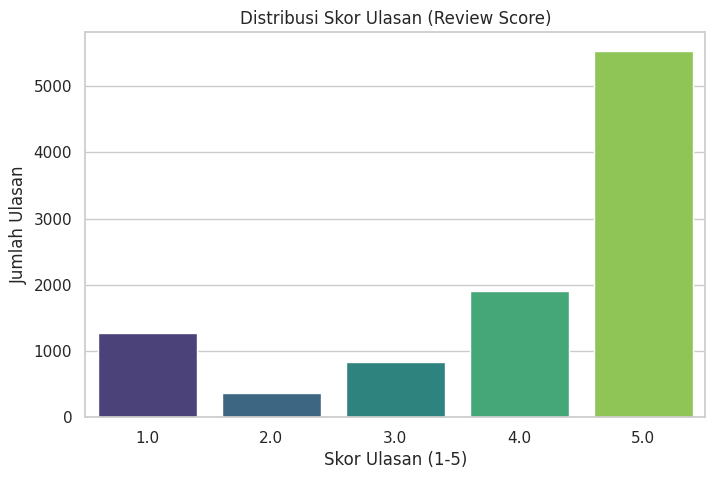

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='review_score', palette='viridis')
plt.title('Distribusi Skor Ulasan (Review Score)')
plt.xlabel('Skor Ulasan (1-5)')
plt.ylabel('Jumlah Ulasan')
plt.show()



/tmp/ipykernel_11288/3571467042.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='payment_type', palette='coolwarm', order=df['payment_type'].value_counts().index)


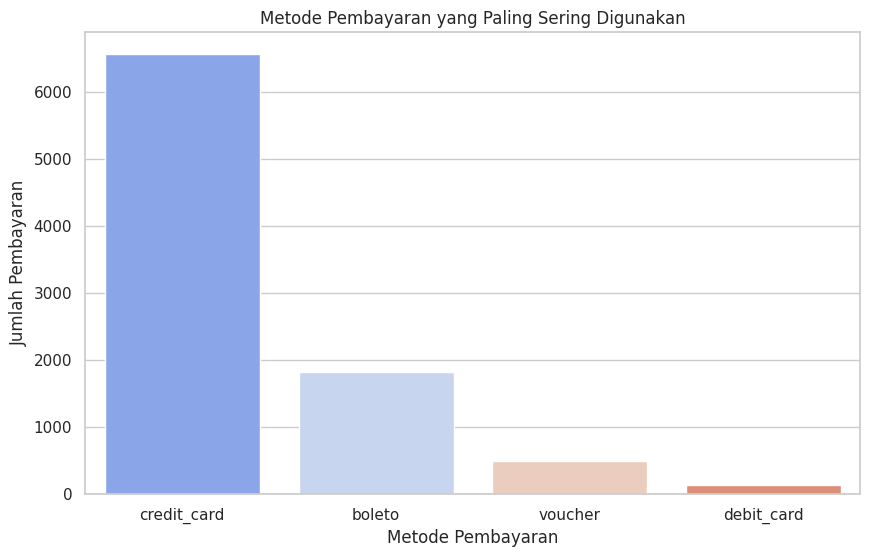

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='payment_type', palette='coolwarm', order=df['payment_type'].value_counts().index)
plt.title('Metode Pembayaran yang Paling Sering Digunakan')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Pembayaran')
plt.show()


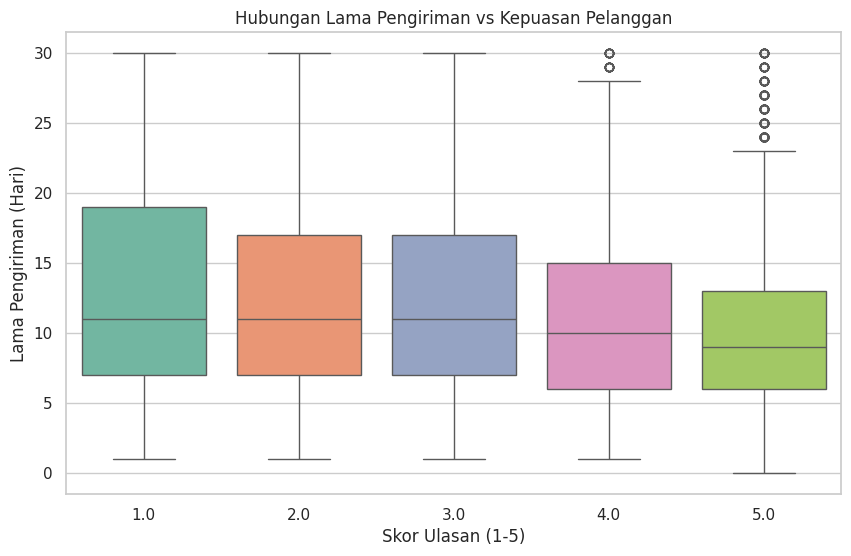

In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['delivery_time_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['delivery_time_days'] <= 30], x='review_score', y='delivery_time_days', palette='Set2', hue='review_score', legend=False)
plt.title('Hubungan Lama Pengiriman vs Kepuasan Pelanggan')
plt.xlabel('Skor Ulasan (1-5)')
plt.ylabel('Lama Pengiriman (Hari)')
plt.show()

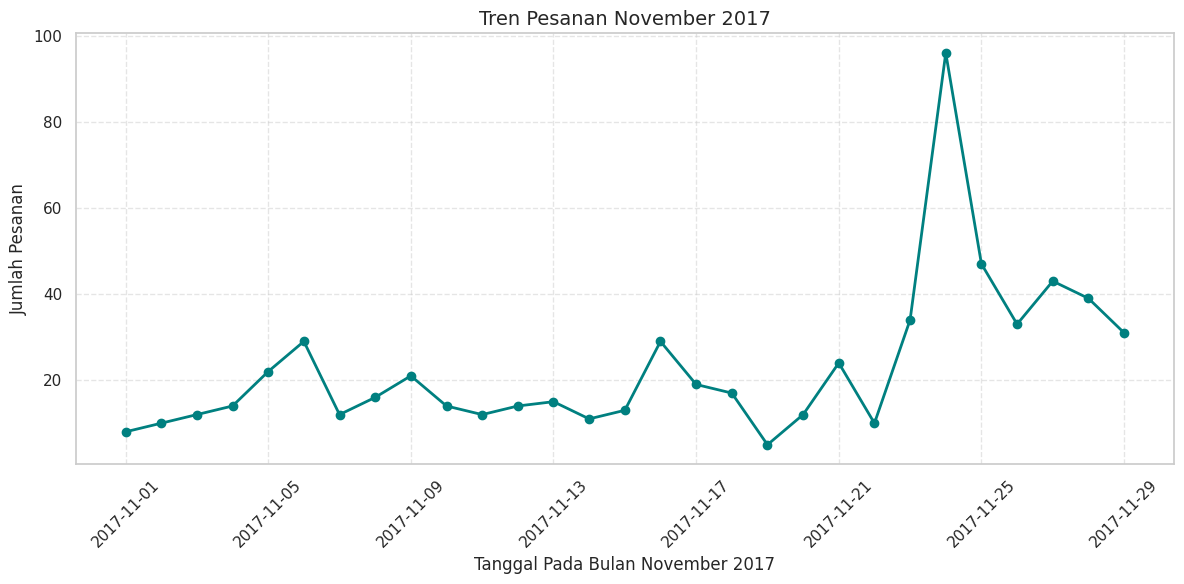

In [ ]:
df = pd.read_csv('master_dataset_cleaned.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

nov_2017 = df[(df['order_purchase_timestamp'] >= '2017-11-01') & (df['order_purchase_timestamp'] <= '2017-11-30')]
daily_orders = nov_2017.groupby(nov_2017['order_purchase_timestamp'].dt.date).size()

plt.figure(figsize=(12, 6))
plt.plot(daily_orders.index, daily_orders.values, marker='o', color='teal', linewidth=2)

plt.title('Tren Pesanan November 2017', fontsize=14)
plt.xlabel('Tanggal Pada Bulan November 2017', fontsize=12)
plt.ylabel('Jumlah Pesanan', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

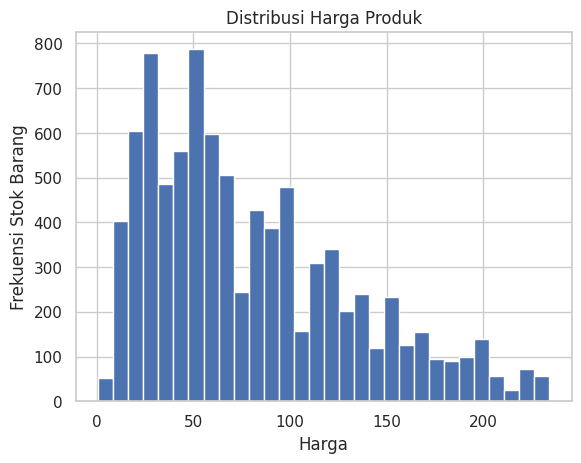

In [ ]:
plt.figure()
df['price'].hist(bins=30)
plt.title('Distribusi Harga Produk')
plt.xlabel('Harga')
plt.ylabel('Frekuensi Stok Barang')
plt.show()

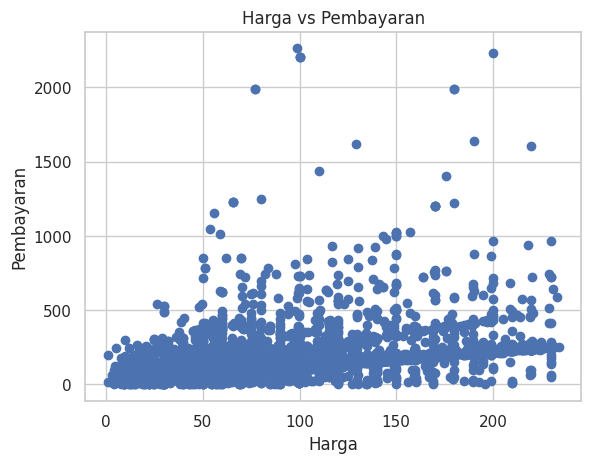

In [ ]:
plt.figure()
plt.scatter(df['price'], df['payment_value'])
plt.title('Harga vs Pembayaran')
plt.xlabel('Harga')
plt.ylabel('Pembayaran')
plt.show()